# 🚀 Mini Portfolio Assignment — E-Commerce Sales Analysis
## Data Analytics Bootcamp

---
**Nama    :** _Wulan Ramadhani_  
**Tanggal :** _Jumat, 16 Mei 2026_  
**Dataset :** [Superstore Sales Dataset](https://kaggle.com/datasets/vivek468/superstore-dataset-final)

### Tujuan Analisis
Sebagai Junior Data Analyst, kita diminta menganalisis data penjualan e-commerce untuk:
1. Memahami performa penjualan per kategori & region
2. Mengidentifikasi dampak diskon terhadap profitabilitas
3. Menemukan pola musiman (seasonal trend)
4. Memberikan rekomendasi bisnis yang actionable

---


## Cell 1 — Import Libraries

In [ ]:
!pip install pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
})
sns.set_palette("husl")

print("✅ Libraries berhasil di-import!")
print(f"   Pandas v{pd.__version__} | NumPy v{np.__version__}")


✅ Libraries berhasil di-import!
   Pandas v2.2.2 | NumPy v2.0.2


## Cell 2 — Load Data
> 💡 Jika file `superstore.csv` belum ada, jalankan fungsi `generate_superstore_data()` di bawah ini untuk membuat sample data.

In [ ]:
def generate_superstore_data(n=2000, seed=42):
    """Generate synthetic e-commerce sales data."""
    np.random.seed(seed)
    rng = pd.date_range("2021-01-01", "2024-12-31", periods=n)
    categories = {
        "Technology":      ["Phones", "Computers", "Accessories", "Copiers"],
        "Furniture":       ["Chairs", "Tables", "Bookcases", "Furnishings"],
        "Office Supplies": ["Binders", "Paper", "Art", "Labels", "Envelopes"],
    }
    segments = ["Consumer", "Corporate", "Home Office"]
    regions  = ["West", "East", "Central", "South"]
    cities   = {
        "West":    ["Los Angeles", "San Francisco", "Seattle", "Portland"],
        "East":    ["New York", "Philadelphia", "Boston", "Atlanta"],
        "Central": ["Chicago", "Dallas", "Houston", "Columbus"],
        "South":   ["Miami", "Tampa", "Nashville", "New Orleans"],
    }
    rows = []
    for i, date in enumerate(rng):
        cat = np.random.choice(list(categories.keys()), p=[0.35, 0.30, 0.35])
        sub = np.random.choice(categories[cat])
        seg = np.random.choice(segments, p=[0.50, 0.30, 0.20])
        reg = np.random.choice(regions)
        city = np.random.choice(cities[reg])
        base_price = {"Technology": 300, "Furniture": 180, "Office Supplies": 30}[cat]
        quantity   = np.random.randint(1, 10)
        price      = base_price * np.random.lognormal(0, 0.5)
        discount   = np.random.choice([0, 0.10, 0.15, 0.20, 0.30, 0.40],
                                       p=[0.45, 0.20, 0.15, 0.10, 0.07, 0.03])
        sales   = round(price * quantity * (1 - discount), 2)
        profit  = round(sales * (0.25 - discount * 1.5 + np.random.normal(0, 0.05)), 2)
        rows.append({"Order ID": f"CA-{2021+i%4}-{100000+i}",
                     "Order Date": date, "Ship Date": date + pd.Timedelta(days=np.random.randint(2,8)),
                     "Customer Name": f"Customer_{np.random.randint(1,500):04d}",
                     "Segment": seg, "City": city, "Region": reg,
                     "Category": cat, "Sub-Category": sub,
                     "Quantity": quantity, "Sales": sales,
                     "Discount": discount, "Profit": profit})
    df = pd.DataFrame(rows)
    for col in ["City", "Customer Name"]:
        df.loc[df.sample(frac=0.02).index, col] = np.nan
    return df

try:
    df_raw = pd.read_csv("superstore.csv",
                         encoding="latin-1",          # ← tambah ini
                         parse_dates=["Order Date", "Ship Date"])
    print("✅ File superstore.csv berhasil dimuat!")
except FileNotFoundError:
    print("⚠️  File tidak ditemukan — membuat sample data...")
    df_raw = generate_superstore_data()
    df_raw.to_csv("superstore_sample.csv", index=False)
    print("✅ Sample data dibuat & disimpan ke 'superstore_sample.csv'")

print(f"\n📐 Shape: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
df_raw.head()


⚠️  File tidak ditemukan — membuat sample data...
✅ Sample data dibuat & disimpan ke 'superstore_sample.csv'

📐 Shape: 2,000 baris × 13 kolom


,Order ID,Order Date,Ship Date,Customer Name,Segment,City,Region,Category,Sub-Category,Quantity,Sales,Discount,Profit
0,CA-2021-100000,2021-01-01 00:00:00.000000000,2021-01-07 00:00:00.000000000,Customer_0100,Consumer,Miami,South,Furniture,Chairs,5,800.57,0.0,190.77
1,CA-2022-100001,2021-01-01 17:31:43.551775887,2021-01-03 17:31:43.551775887,Customer_0049,Consumer,Atlanta,East,Technology,Accessories,6,3739.59,0.0,1222.61
2,CA-2023-100002,2021-01-02 11:03:27.103551775,2021-01-08 11:03:27.103551775,Customer_0307,Consumer,New Orleans,South,Furniture,Bookcases,3,521.88,0.1,51.28
3,CA-2024-100003,2021-01-03 04:35:10.655327663,2021-01-08 04:35:10.655327663,Customer_0367,Consumer,Miami,South,Office Supplies,Binders,2,55.94,0.0,13.89
4,CA-2021-100004,2021-01-03 22:06:54.207103551,2021-01-10 22:06:54.207103551,Customer_0054,Consumer,Houston,Central,Office Supplies,Labels,1,45.26,0.0,8.55


## Cell 3 — Step 1: Data Exploration

In [ ]:
print("=== INFO DATASET ===")
df_raw.info()


=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       2000 non-null   object        
 1   Order Date     2000 non-null   datetime64[ns]
 2   Ship Date      2000 non-null   datetime64[ns]
 3   Customer Name  1960 non-null   object        
 4   Segment        2000 non-null   object        
 5   City           1960 non-null   object        
 6   Region         2000 non-null   object        
 7   Category       2000 non-null   object        
 8   Sub-Category   2000 non-null   object        
 9   Quantity       2000 non-null   int64         
 10  Sales          2000 non-null   float64       
 11  Discount       2000 non-null   float64       
 12  Profit         2000 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(7)
memory usage: 203.3+ KB


In [ ]:
print("=== STATISTIK DESKRIPTIF ===")
df_raw.describe().round(2)


=== STATISTIK DESKRIPTIF ===


,Order Date,Ship Date,Quantity,Sales,Discount,Profit
count,2000,2000,2000.00,2000.00,2000.00,2000.00
mean,2023-01-01 00:00:00,2023-01-05 12:47:31.200000,4.87,841.48,0.09,110.03
min,2021-01-01 00:00:00,2021-01-03 17:31:43.551775887,1.00,6.26,0.00,-729.30
25%,2022-01-01 00:00:00,2022-01-06 07:49:18.879439872,3.00,153.97,0.00,1.86
50%,2023-01-01 00:00:00,2023-01-04 19:24:49.344672256,5.00,433.24,0.10,34.20
75%,2024-01-01 00:00:00,2024-01-04 20:45:51.775887872,7.00,1162.05,0.15,139.62
max,2024-12-31 00:00:00,2025-01-05 12:56:32.896448224,9.00,10627.91,0.40,3883.39
std,NaN,NaN,2.59,1046.65,0.11,265.69


In [ ]:
print("=== MISSING VALUES ===")
missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({"Count": missing, "Pct %": pct})[missing > 0]


=== MISSING VALUES ===


,Count,Pct %
Customer Name,40,2.0
City,40,2.0


In [ ]:
# Distribusi setiap kolom kategorik
for col in ["Category", "Segment", "Region"]:
    if col in df_raw.columns:
        print(f"\n{col}:")
        print(df_raw[col].value_counts())



Category:
Category
Office Supplies    719
Technology         679
Furniture          602
Name: count, dtype: int64

Segment:
Segment
Consumer       1014
Corporate       578
Home Office     408
Name: count, dtype: int64

Region:
Region
South      517
West       512
East       489
Central    482
Name: count, dtype: int64


## Cell 4 — Step 2: Data Cleaning

In [ ]:
df = df_raw.copy()

# 1. Drop missing values di kolom kritis
df = df.dropna(subset=["Sales", "Profit", "Category"])

# 2. Isi missing City
df["City"] = df["City"].fillna("Unknown")

# 3. Remove duplicates
df = df.drop_duplicates()

# 4. Fix data types
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"]  = pd.to_datetime(df["Ship Date"])

# 5. Feature Engineering
df["Year"]          = df["Order Date"].dt.year
df["Month"]         = df["Order Date"].dt.month
df["Month_Name"]    = df["Order Date"].dt.strftime("%b")
df["Quarter"]       = df["Order Date"].dt.quarter.map({1:"Q1",2:"Q2",3:"Q3",4:"Q4"})
df["Ship_Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Profit_Margin"] = (df["Profit"] / df["Sales"] * 100).round(2)
df["Is_Profitable"] = df["Profit"] > 0

print(f"✅ Data bersih: {df.shape[0]:,} baris × {df.shape[1]} kolom")
df.head()


✅ Data bersih: 2,000 baris × 20 kolom


,Order ID,Order Date,Ship Date,Customer Name,Segment,City,Region,Category,Sub-Category,Quantity,Sales,Discount,Profit,Year,Month,Month_Name,Quarter,Ship_Duration,Profit_Margin,Is_Profitable
0,CA-2021-100000,2021-01-01 00:00:00.000000000,2021-01-07 00:00:00.000000000,Customer_0100,Consumer,Miami,South,Furniture,Chairs,5,800.57,0.0,190.77,2021,1,Jan,Q1,6,23.83,True
1,CA-2022-100001,2021-01-01 17:31:43.551775887,2021-01-03 17:31:43.551775887,Customer_0049,Consumer,Atlanta,East,Technology,Accessories,6,3739.59,0.0,1222.61,2021,1,Jan,Q1,2,32.69,True
2,CA-2023-100002,2021-01-02 11:03:27.103551775,2021-01-08 11:03:27.103551775,Customer_0307,Consumer,New Orleans,South,Furniture,Bookcases,3,521.88,0.1,51.28,2021,1,Jan,Q1,6,9.83,True
3,CA-2024-100003,2021-01-03 04:35:10.655327663,2021-01-08 04:35:10.655327663,Customer_0367,Consumer,Miami,South,Office Supplies,Binders,2,55.94,0.0,13.89,2021,1,Jan,Q1,5,24.83,True
4,CA-2021-100004,2021-01-03 22:06:54.207103551,2021-01-10 22:06:54.207103551,Customer_0054,Consumer,Houston,Central,Office Supplies,Labels,1,45.26,0.0,8.55,2021,1,Jan,Q1,7,18.89,True


## Cell 5 — Step 3: Sales Analysis
### KPI Summary

In [ ]:
total_sales   = df["Sales"].sum()
total_profit  = df["Profit"].sum()
total_orders  = df["Order ID"].nunique()
avg_order_val = df.groupby("Order ID")["Sales"].sum().mean()
profit_margin = total_profit / total_sales * 100

kpi = pd.DataFrame({
    "KPI": ["Total Revenue", "Total Profit", "Total Orders",
            "Avg Order Value", "Profit Margin", "% Profitable Trans"],
    "Value": [
        f"${total_sales:,.2f}", f"${total_profit:,.2f}", f"{total_orders:,}",
        f"${avg_order_val:,.2f}", f"{profit_margin:.1f}%",
        f"{df['Is_Profitable'].mean()*100:.1f}%"
    ]
})
kpi


,KPI,Value
0,Total Revenue,"$1,682,958.66"
1,Total Profit,"$220,069.12"
2,Total Orders,"2,000"
3,Avg Order Value,$841.48
4,Profit Margin,13.1%
5,% Profitable Trans,77.1%


### Sales by Category

In [ ]:
sales_by_cat = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Num_Orders=("Order ID", "count"),
).sort_values("Total_Sales", ascending=False)
sales_by_cat["Margin_%"] = (sales_by_cat["Total_Profit"]/sales_by_cat["Total_Sales"]*100).round(1)
sales_by_cat.style.format({"Total_Sales":"${:,.0f}", "Total_Profit":"${:,.0f}", "Margin_%":"{:.1f}%"})


,Total_Sales,Total_Profit,Num_Orders,Margin_%
Category,,,,
Technology,"$1,034,029","$142,583",679,13.8%
Furniture,"$544,036","$64,835",602,11.9%
Office Supplies,"$104,894","$12,651",719,12.1%


## Cell 6 — Step 4: Visualisasi
### Dashboard (4 Charts)

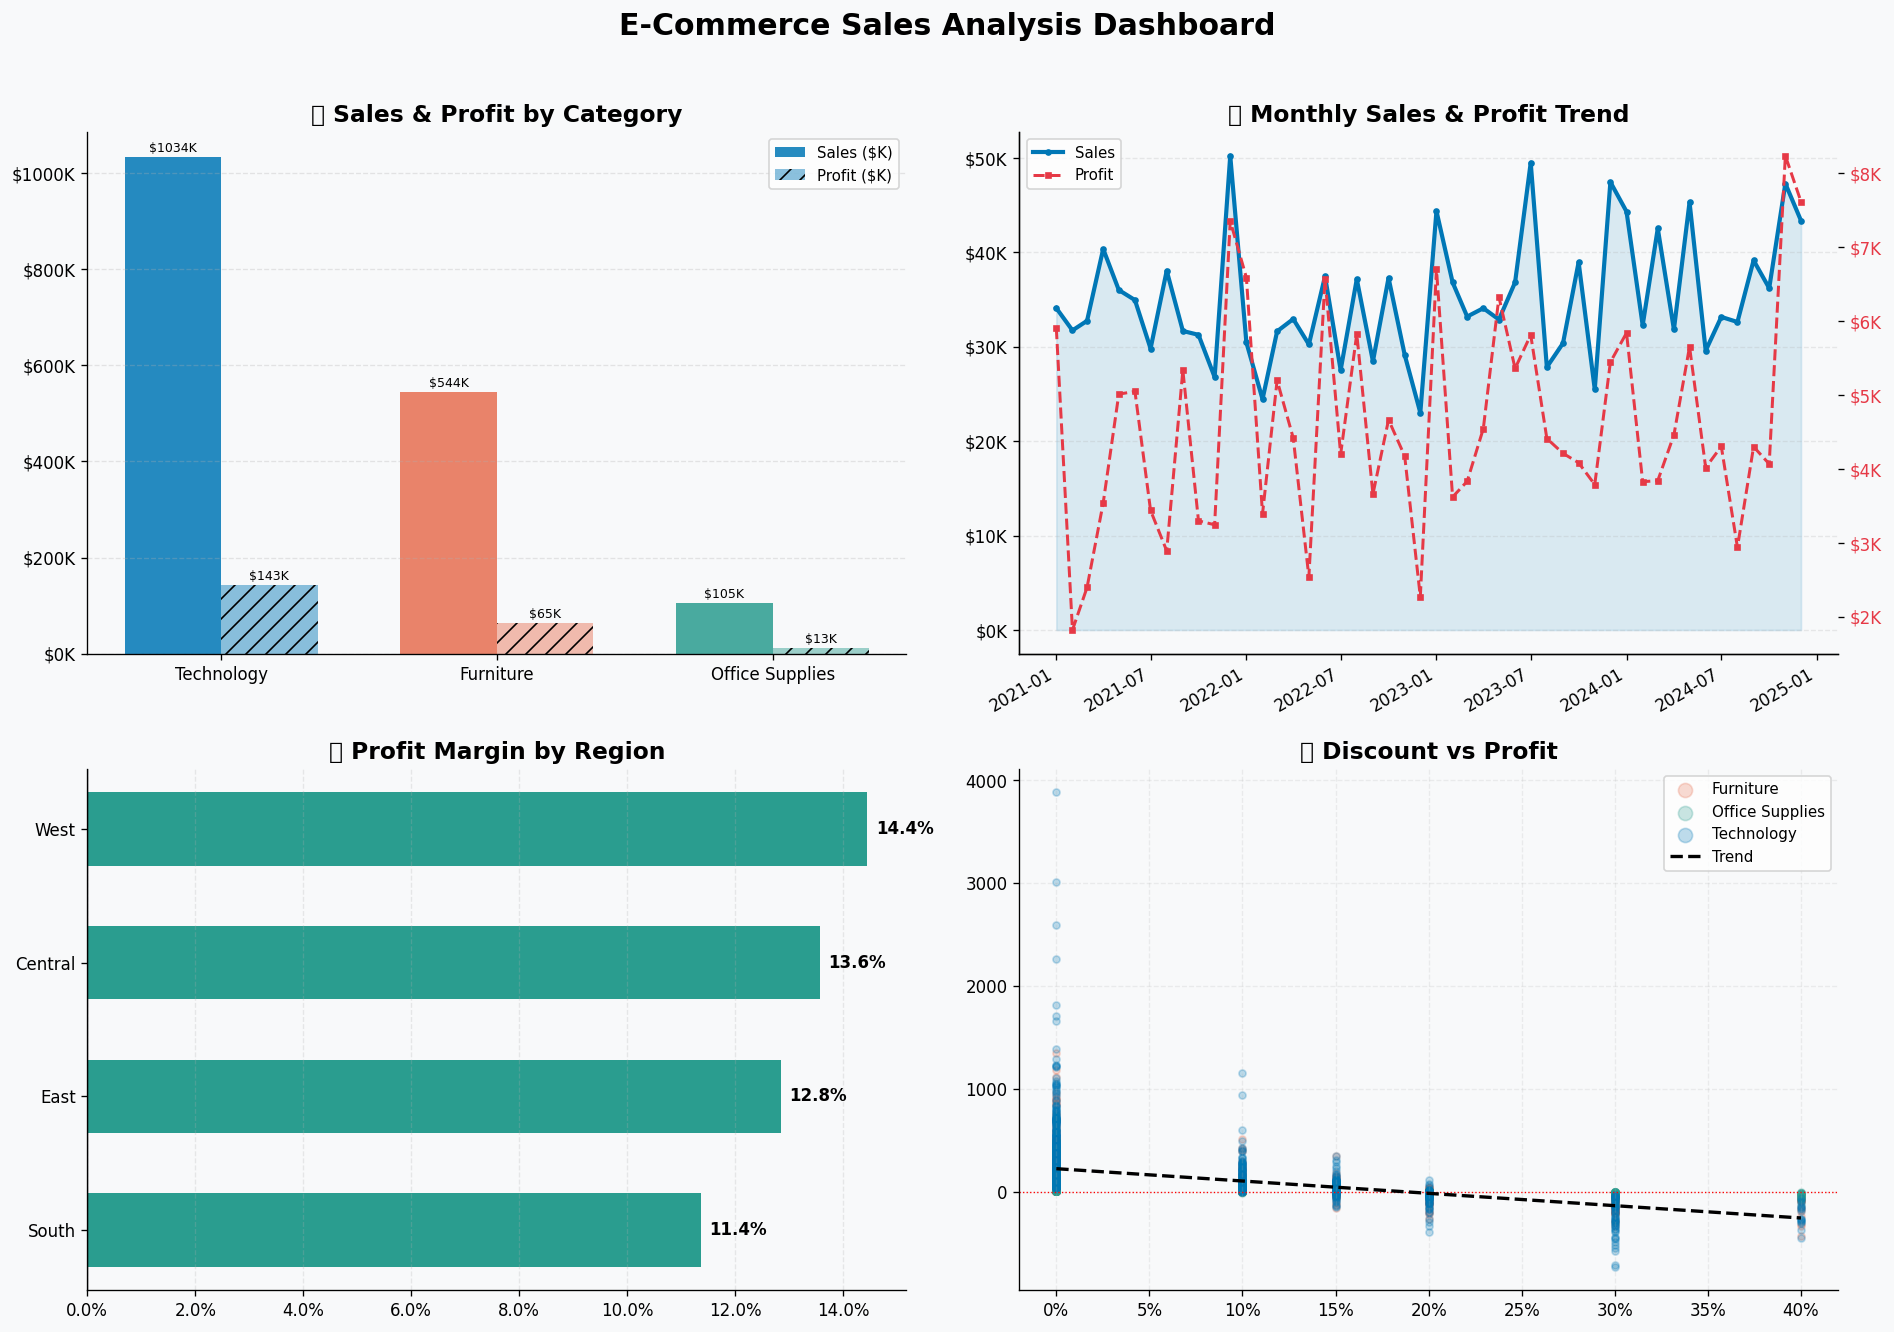

✅ Dashboard disimpan ke dashboard_charts.png


In [ ]:
COLORS_CAT = {"Technology": "#0077B6", "Furniture": "#E76F51", "Office Supplies": "#2A9D8F"}
FIG_COLOR  = "#F8F9FA"

monthly = df.groupby(["Year","Month"]).agg(Sales=("Sales","sum"),Profit=("Profit","sum")).reset_index()
monthly["Date"] = pd.to_datetime(monthly[["Year","Month"]].assign(Day=1))
monthly = monthly.sort_values("Date")

region_margin = df.groupby("Region").agg(Sales=("Sales","sum"),Profit=("Profit","sum"))
region_margin["Margin"] = region_margin["Profit"]/region_margin["Sales"]*100

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor(FIG_COLOR)
fig.suptitle("E-Commerce Sales Analysis Dashboard", fontsize=18, fontweight="bold", y=1.01)

# Chart 1 — Sales & Profit by Category
ax1 = axes[0,0]; ax1.set_facecolor(FIG_COLOR)
cats = sales_by_cat.index.tolist(); x = np.arange(len(cats)); w = 0.35
b1 = ax1.bar(x-w/2, sales_by_cat["Total_Sales"]/1e3, w,
             color=[COLORS_CAT.get(c,"#888") for c in cats], alpha=0.85, label="Sales ($K)")
b2 = ax1.bar(x+w/2, sales_by_cat["Total_Profit"]/1e3, w,
             color=[COLORS_CAT.get(c,"#888") for c in cats], alpha=0.45, hatch="//", label="Profit ($K)")
ax1.set_xticks(x); ax1.set_xticklabels(cats)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}K"))
ax1.set_title("💰 Sales & Profit by Category"); ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3, ls="--")
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax1.annotate(f"${h:.0f}K", xy=(bar.get_x()+bar.get_width()/2, h),
                 xytext=(0,3), textcoords="offset points", ha="center", fontsize=7.5)

# Chart 2 — Monthly Trend
ax2 = axes[0,1]; ax2.set_facecolor(FIG_COLOR)
ax2.plot(monthly["Date"], monthly["Sales"]/1e3, color="#0077B6", lw=2.5, marker="o", ms=3, label="Sales")
ax2.fill_between(monthly["Date"], monthly["Sales"]/1e3, alpha=0.12, color="#0077B6")
ax2b = ax2.twinx()
ax2b.plot(monthly["Date"], monthly["Profit"]/1e3, color="#E63946", lw=1.8, ls="--", ms=3, marker="s", label="Profit")
ax2b.tick_params(axis="y", labelcolor="#E63946")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}K"))
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:.0f}K"))
ax2.set_title("📈 Monthly Sales & Profit Trend")
l1,la1=ax2.get_legend_handles_labels(); l2,la2=ax2b.get_legend_handles_labels()
ax2.legend(l1+l2,la1+la2,fontsize=9,loc="upper left")
ax2.grid(axis="y", alpha=0.25, ls="--"); plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

# Chart 3 — Region Profit Margin
ax3 = axes[1,0]; ax3.set_facecolor(FIG_COLOR)
rm = region_margin.sort_values("Margin")
colors3 = ["#E63946" if m<0 else "#2A9D8F" if m<15 else "#0077B6" for m in rm["Margin"]]
b3 = ax3.barh(rm.index, rm["Margin"], color=colors3, height=0.55)
ax3.axvline(0, color="black", lw=0.8)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.1f}%"))
ax3.set_title("🗺️ Profit Margin by Region"); ax3.grid(axis="x", alpha=0.25, ls="--")
for bar in b3:
    w2 = bar.get_width()
    ax3.annotate(f"{w2:.1f}%", xy=(w2, bar.get_y()+bar.get_height()/2),
                 xytext=(5,0), textcoords="offset points", va="center", fontsize=10, fontweight="bold")

# Chart 4 — Discount vs Profit
ax4 = axes[1,1]; ax4.set_facecolor(FIG_COLOR)
for cat, grp in df.groupby("Category"):
    ax4.scatter(grp["Discount"], grp["Profit"], alpha=0.25,
                label=cat, s=18, color=COLORS_CAT.get(cat,"#888"))
from numpy.polynomial.polynomial import polyfit
c = polyfit(df["Discount"].values, df["Profit"].values, 1)
xl = np.linspace(df["Discount"].min(), df["Discount"].max(), 100)
ax4.plot(xl, c[0]+c[1]*xl, color="black", lw=2, ls="--", label="Trend", zorder=5)
ax4.axhline(0, color="red", lw=0.8, ls=":")
ax4.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0%}"))
ax4.set_title("🎯 Discount vs Profit"); ax4.legend(fontsize=9, markerscale=2)
ax4.grid(alpha=0.2, ls="--")

plt.tight_layout(pad=1.5)
plt.savefig("dashboard_charts.png", bbox_inches="tight", dpi=150, facecolor=FIG_COLOR)
plt.show()
print("✅ Dashboard disimpan ke dashboard_charts.png")


### Bonus: Heatmap Sales

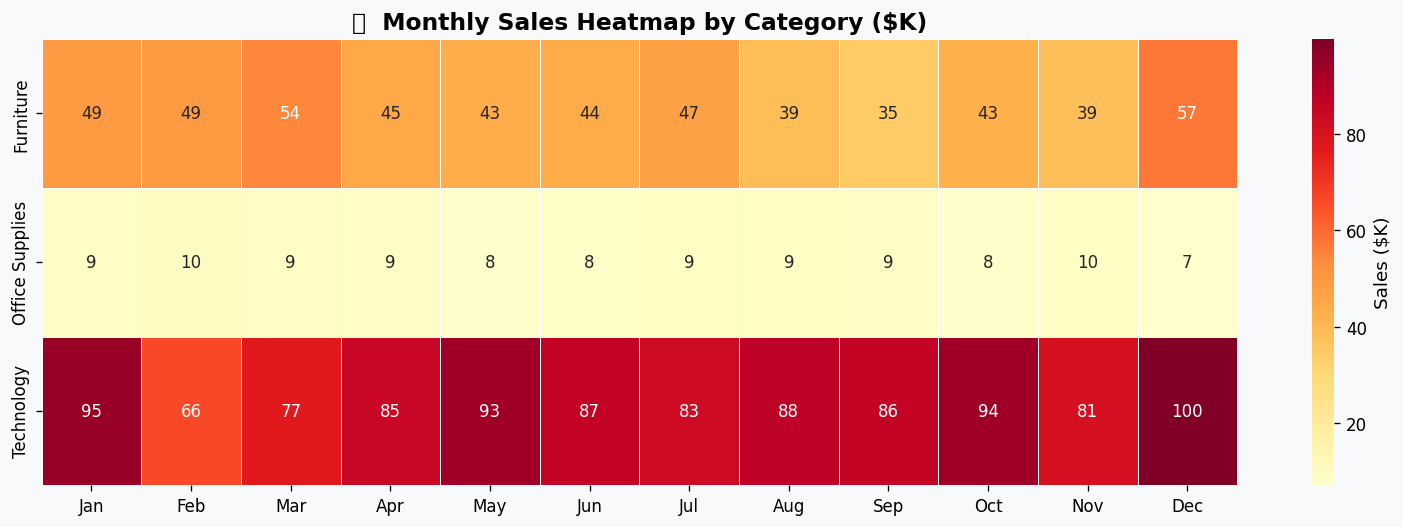

In [ ]:
fig_h, ax_h = plt.subplots(figsize=(13, 4.5))
fig_h.patch.set_facecolor("#F8F9FA"); ax_h.set_facecolor("#F8F9FA")

hm = df.pivot_table(values="Sales", index="Category", columns="Month_Name", aggfunc="sum")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
hm = hm.reindex(columns=[m for m in month_order if m in hm.columns])

sns.heatmap(hm/1e3, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white", ax=ax_h,
            cbar_kws={"label": "Sales ($K)"})
ax_h.set_title("🗓️  Monthly Sales Heatmap by Category ($K)", fontsize=14, fontweight="bold")
ax_h.set_xlabel(""); ax_h.set_ylabel("")
plt.tight_layout()
plt.savefig("heatmap_sales.png", bbox_inches="tight", dpi=150)
plt.show()


## Cell 7 — Step 5: Business Insights
> ✏️ **Isi insight-mu di sini!** Ubah teks placeholder dengan temuan dari analisismu.

In [ ]:
# Hitung beberapa angka pendukung insight
high_disc_loss = df[df["Discount"] >= 0.30]["Profit"].mean()
low_disc_prof  = df[df["Discount"] <= 0.10]["Profit"].mean()
best_region    = region_margin["Margin"].idxmax()
best_mg        = region_margin["Margin"].max()
all_subcats = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
high_subcat = all_subcats.index[0]
low_subcat  = all_subcats.index[-1]

print("=" * 55)
print("📊 BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 55)
print(f"""
💡 INSIGHT 1 — DISCOUNT POLICY
   Transaksi diskon ≥30% rata-rata profit: ${high_disc_loss:,.1f}
   Transaksi diskon ≤10% rata-rata profit: ${low_disc_prof:,.1f}
   → Kurangi diskon agresif, batas maks 20%

💡 INSIGHT 2 — REGIONAL PERFORMANCE
   Region terbaik: {best_region} (margin {best_mg:.1f}%)
   → Replikasi strategi {best_region} ke region lain

💡 INSIGHT 3 — HIGHEST SALES
   Produk dengan penjualan tertinggi: {high_subcat}
   Produk dengan penjualan terendah: {low_subcat}
   -> Fokus meningkatkan penjualan dan promosi untuk produk penjualan tertinggi

💡 REKOMENDASI:
   1. Tetapkan diskon dalam batas wajar 10-20% supaya margin keuntungan stabil
   2. Pertimbangkan personalisasi produk yang ditawarkan berdasarkan produk
   paling laris per region
   3. Evaluasi kualitas produk penjualan terendah, pertimbangkan inovasi produk
""")


📊 BUSINESS INSIGHTS & RECOMMENDATIONS

💡 INSIGHT 1 — DISCOUNT POLICY
   Transaksi diskon ≥30% rata-rata profit: $-136.9
   Transaksi diskon ≤10% rata-rata profit: $192.9
   → Kurangi diskon agresif, batas maks 20%

💡 INSIGHT 2 — REGIONAL PERFORMANCE
   Region terbaik: West (margin 14.4%)
   → Replikasi strategi West ke region lain

💡 INSIGHT 3 — HIGHEST SALES
   Produk dengan penjualan tertinggi: Phones
   Produk dengan penjualan terendah: Labels
   -> Fokus meningkatkan penjualan dan promosi untuk produk penjualan tertinggi

💡 REKOMENDASI:
   1. Tetapkan diskon dalam batas wajar 10-20% supaya margin keuntungan stabil
   2. Pertimbangkan personalisasi produk yang ditawarkan berdasarkan produk 
   paling laris per region
   3. Evaluasi kualitas produk penjualan terendah, pertimbangkan inovasi produk



## Cell 8 — ✏️ YOUR TURN — Challenge Tasks

Selesaikan tasks berikut untuk memperkuat portfolio kamu:

In [ ]:
# LEVEL 1: Wajib diselesaikan

# Task 1: Hitung CLV sederhana
clv = df.groupby("Customer Name")["Sales"].agg(["sum","count"])
clv.columns = ["Total_Spend", "Num_Orders"]
clv["Avg_Order"] = clv["Total_Spend"] / clv["Num_Orders"]
print(clv.sort_values("Total_Spend", ascending=False).head(10))

# Task 2: Top 5 Sub-Category paling rugi
print(df.groupby("Sub-Category")["Profit"].sum().sort_values().head(5))

# Task 3: Profitabilitas per Segment
print(df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum")))

# ── Hapus komentar (#) di atas untuk menjalankan ──────────────────────────
print("💡 Hapus komentar di cell ini satu per satu dan jalankan!")


               Total_Spend  Num_Orders    Avg_Order
Customer Name                                      
Customer_0310     20156.66           8  2519.582500
Customer_0012     14477.94           8  1809.742500
Customer_0428     12702.76           9  1411.417778
Customer_0143     12125.95           6  2020.991667
Customer_0049     11852.71           9  1316.967778
Customer_0482     11588.81          13   891.446923
Customer_0077     11563.70           7  1651.957143
Customer_0166     10837.62          10  1083.762000
Customer_0444     10479.74           7  1497.105714
Customer_0050     10463.48           6  1743.913333
Sub-Category
Labels       2158.45
Art          2415.89
Envelopes    2572.61
Paper        2669.01
Binders      2835.31
Name: Profit, dtype: float64
                 Sales     Profit
Segment                          
Consumer     856232.69  111688.66
Corporate    462744.14   63857.25
Home Office  363981.83   44523.21
💡 Hapus komentar di cell ini satu per satu dan jalankan!


### 📊 Visualisasi Customer Lifetime Value (CLV)
Visualisasi ini membantu kita mengidentifikasi segmen pelanggan berdasarkan total belanja dan frekuensi order.

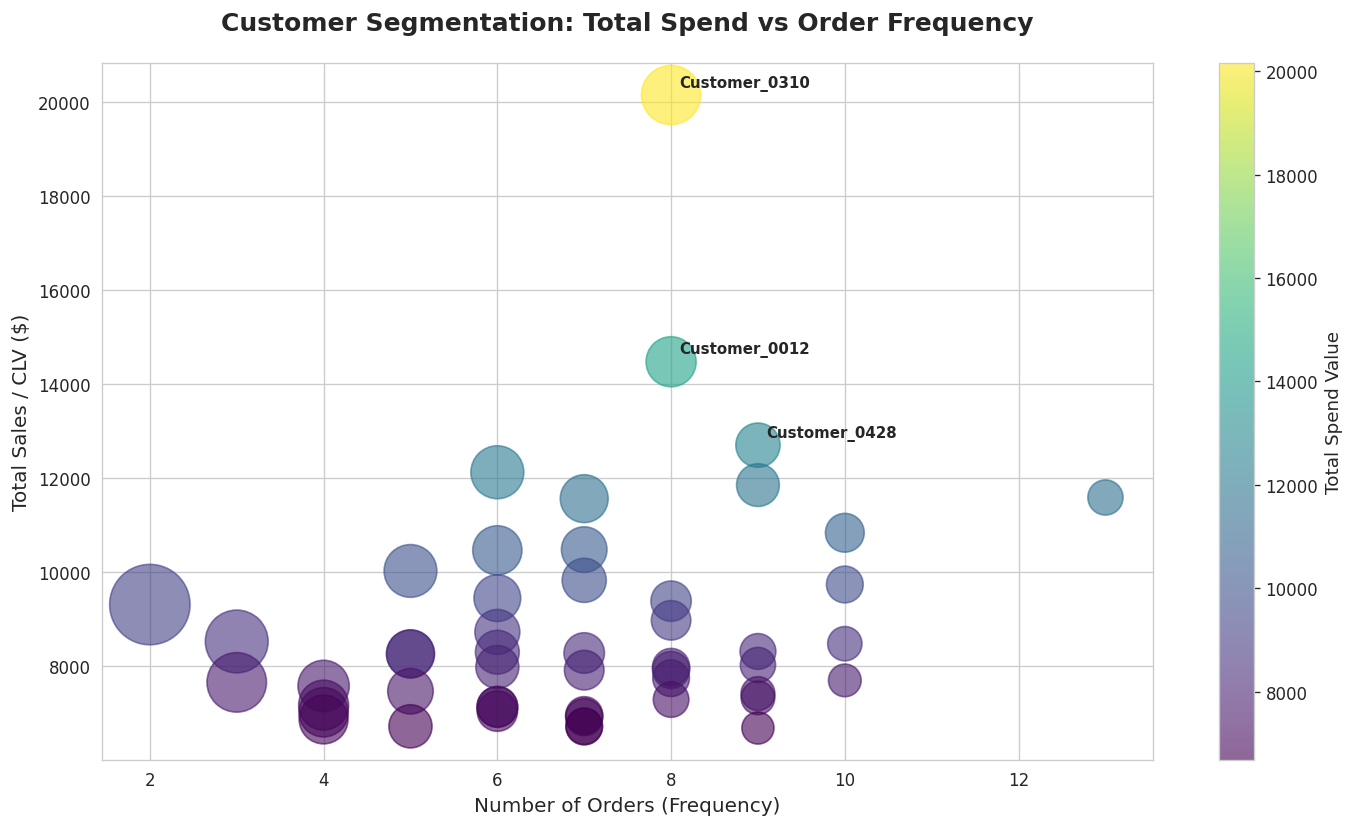

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil data top 50 untuk menjaga keterbacaan chart
clv_plot = clv.sort_values("Total_Spend", ascending=False).head(50)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Create Scatter Plot
scatter = plt.scatter(
    x=clv_plot['Num_Orders'],
    y=clv_plot['Total_Spend'],
    s=clv_plot['Avg_Order']*0.5, # Ukuran bubble berdasarkan rata-rata order
    alpha=0.6,
    c=clv_plot['Total_Spend'],
    cmap='viridis'
)

# Tambahkan Label
plt.title('Customer Segmentation: Total Spend vs Order Frequency', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Orders (Frequency)', fontsize=12)
plt.ylabel('Total Sales / CLV ($)', fontsize=12)
plt.colorbar(scatter, label='Total Spend Value')

# Highlight Top 3 Customers
for i, txt in enumerate(clv_plot.index[:3]):
    plt.annotate(txt, (clv_plot['Num_Orders'].iloc[i], clv_plot['Total_Spend'].iloc[i]),
                 xytext=(5,5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("clv_sederhana.png", bbox_inches="tight", dpi=150)
plt.show()

### 📉 Visualisasi Sub-Kategori Paling Rugi
Analisis ini fokus pada produk yang menggerus profitabilitas perusahaan.

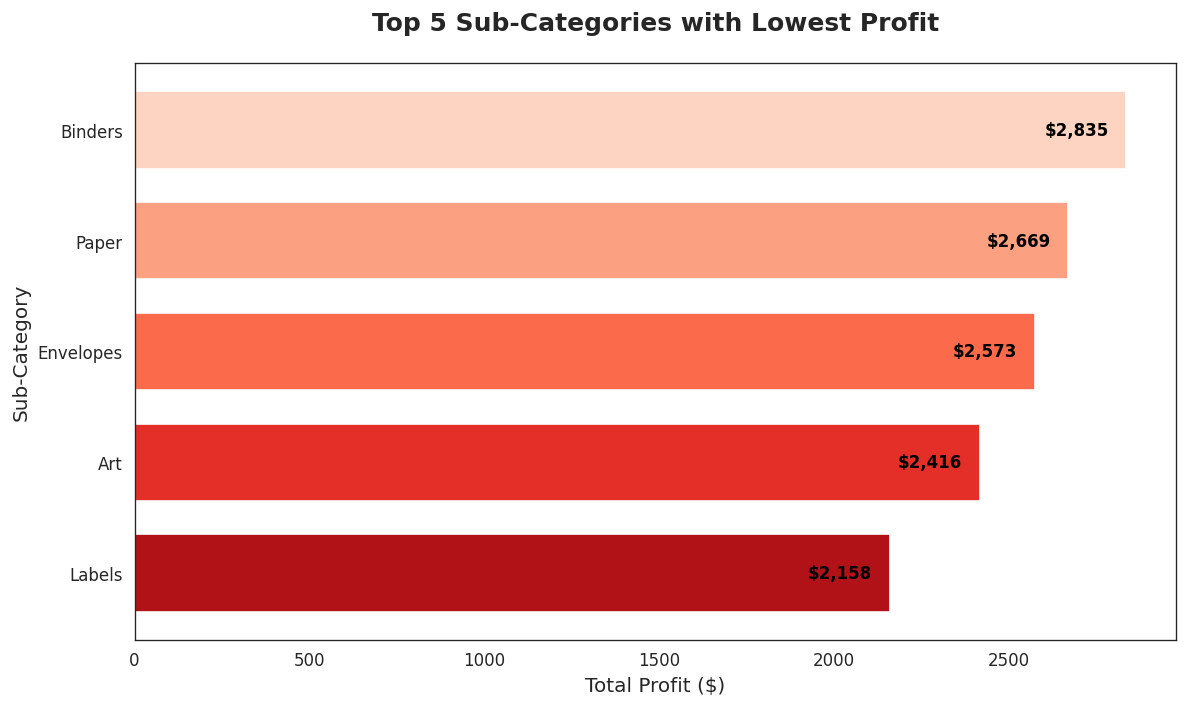

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung Top 5 Sub-Category paling rugi (Profit terkecil/negatif terbanyak)
most_loss = df.groupby("Sub-Category")["Profit"].sum().sort_values().head(5)

# Setup Plot
plt.figure(figsize=(10, 6))
sns.set_style("white")

# Membuat bar chart (Warna merah untuk menekankan kerugian)
colors = sns.color_palette("Reds_r", n_colors=len(most_loss))
ax = most_loss.plot(kind='barh', color=colors, width=0.7)

# Kustomisasi Tampilan
plt.title('Top 5 Sub-Categories with Lowest Profit', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Garis tengah di angka 0

# Menambahkan label angka di setiap bar
for i, v in enumerate(most_loss):
    ax.text(v - 50, i, f'${v:,.0f}', color='black', va='center', ha='right', fontweight='bold')

plt.tight_layout()
plt.savefig("lowest_profit.png", bbox_inches="tight", dpi=150)
plt.show()

### 📈 Visualisasi Profitabilitas per Segment
Analisis ini membandingkan kontribusi penjualan dan laba bersih dari setiap segmen pelanggan (Consumer, Corporate, Home Office).

<Figure size 1200x720 with 0 Axes>

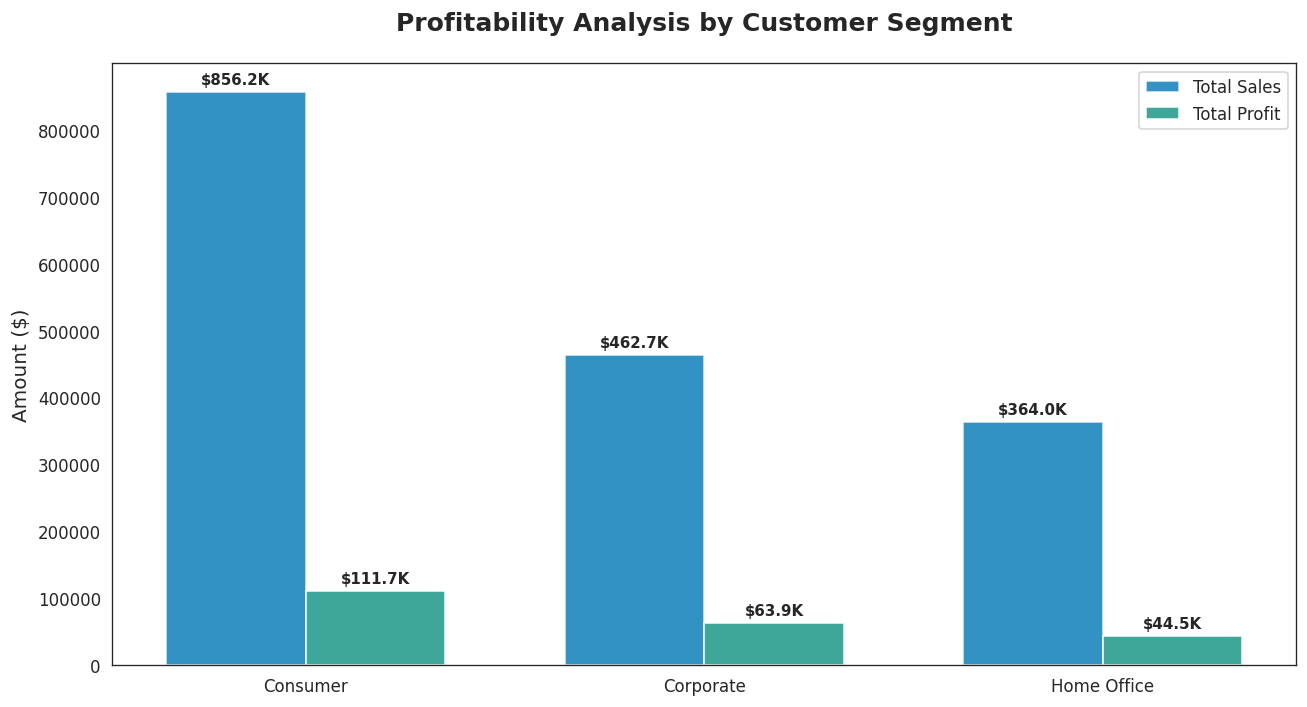

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Menyiapkan data dari Task 3
segment_data = df.groupby("Segment").agg(Sales=("Sales","sum"), Profit=("Profit","sum")).sort_values("Sales", ascending=False)

# Setup plot
plt.figure(figsize=(10, 6))
sns.set_style("white")

segments = segment_data.index
x = np.arange(len(segments))
width = 0.35

# Membuat Grouped Bar
fig, ax = plt.subplots(figsize=(11, 6))
bar1 = ax.bar(x - width/2, segment_data['Sales'], width, label='Total Sales', color='#0077B6', alpha=0.8)
bar2 = ax.bar(x + width/2, segment_data['Profit'], width, label='Total Profit', color='#2A9D8F', alpha=0.9)

# Labeling
ax.set_title('Profitability Analysis by Customer Segment', fontsize=15, fontweight='bold', pad=20)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.legend()

# Menambahkan label nilai di atas bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'${height/1e3:.1f}K',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(bar1)
autolabel(bar2)

plt.tight_layout()
plt.savefig("segment_profitability.png", bbox_inches="tight", dpi=150)
plt.show()

#### **Insight untuk Segmentasi:**
*   **Dominasi Segmen**: Biasanya segmen **Consumer** memberikan volume penjualan terbesar, namun perhatikan apakah margin profitnya sebanding dengan segmen **Corporate**.
*   **Efisiensi Biaya**: Jika ada segmen dengan bar Sales tinggi tapi Profit sangat rendah, itu adalah indikasi biaya akuisisi pelanggan (CAC) atau diskon di segmen tersebut perlu ditinjau ulang.

#### **Rekomendasi Strategis:**
*   **Evaluasi Harga**: Jika kategori tersebut (seperti *Labels* atau *Art* pada data ini) memiliki profit rendah, periksa apakah biaya pengiriman atau diskon terlalu tinggi.
*   **Bundling**: Pertimbangkan untuk memaketkan produk yang rugi dengan produk yang sangat menguntungkan (*High Margin*).
*   **Inventory Review**: Jika biaya operasional untuk menyimpan produk ini lebih besar dari profitnya, pertimbangkan untuk mengurangi stok atau beralih ke model *dropship*.

#### **Cara Membaca Insight:**
*   **Kanan Atas (High Frequency, High Spend)**: Pelanggan paling loyal (Loyalists). Pertahankan dengan VIP program.
*   **Kiri Atas (Low Frequency, High Spend)**: Pelanggan yang potensial tapi jarang belanja. Perlu dipicu dengan email marketing atau reminder.
*   **Kanan Bawah (High Frequency, Low Spend)**: Pelanggan 'murah' tapi rajin. Cocok untuk target produk bundling.

---
## 🏁 Next Steps
1. Selesaikan **Challenge Tasks** di Cell 8
2. Simpan sebagai `ecommerce_analysis.ipynb`
3. Upload ke **GitHub** (buat repo: `ecommerce-sales-analysis`)
4. Screenshot **2–3 chart terbaik**
5. Buat **LinkedIn Post** dalam 7 hari!

```
Template Caption LinkedIn:
"[Hook sentence] 💡
📊 Analisis: Superstore Sales Dataset
🛠️ Tools: Python | Pandas | Seaborn
🔍 Key Findings:
• [Insight 1]
• [Insight 2]
• [Insight 3]
👉 Full notebook: [GitHub link]
#DataAnalytics #Python #Portfolio"
```

**Good luck! Kamu pasti bisa 🚀**